In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'RDpcUmVwb3NpdG9yaWVzXEFENjk4LWdlbmVyYXRpdmUtYWktZm9yLUJBXE04XG0wOF9sMDFfY29udGVudA=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\zipimport.py": 1744131414.0, "C:\\Program Files\\Python312\\Lib\\codecs.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\aliases.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\__init__.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\utf_8.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\cp1252.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\abc.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\io.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\stat.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\_collections_abc.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\genericpath.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\ntpath.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\o

In [2]:
#| echo: true
#| eval: true

import math
import numpy as np
import time

# Pytorch is the default framework, but we can also use TensorFlow, JAX, and MXNet.
import torch

# tensorflow is not a default dependency, so we need to import it conditionally
import tensorflow as tf

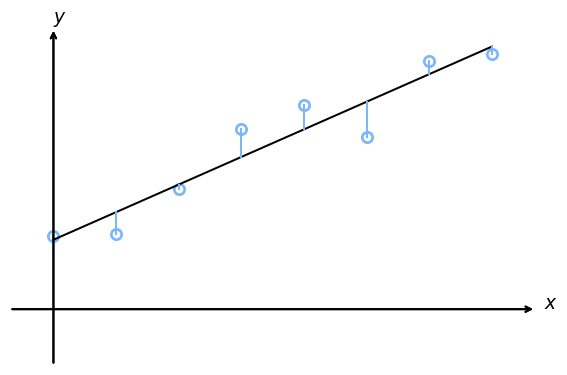

In [3]:
#| echo: true
#| eval: true
#| label: fig-fit_linreg
#| fig-cap: Fitting a linear regression model to one-dimensional data.
#| fig-alt: A line plot on cartesian coordinates

import numpy as np
import matplotlib.pyplot as plt

# --- synthetic data (you can replace with real data) ---
np.random.seed(0)
x = np.linspace(0, 10, 8)
y = 2.0 * x + 3 + np.random.normal(scale=2.0, size=len(x))

# --- fit linear regression ---
coef = np.polyfit(x, y, 1)
m, b = coef
y_pred = m * x + b

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 4))

# regression line
ax.plot(x, y_pred, color="black", linewidth=1.5)

# data points
ax.scatter(x, y, s=60, facecolor="white", edgecolor="#7ab6f9", linewidth=2)

# residual lines (vertical distances)
for xi, yi, ypi in zip(x, y, y_pred):
    ax.plot([xi, xi], [yi, ypi], color="#7ab6f9", linewidth=1.5)

# axes arrows (to mimic the SVG)
ax.annotate("", xy=(11, 0), xytext=(-1, 0),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))
ax.annotate("", xy=(0, 25), xytext=(0, -5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))

# Axis arrows 
ax.annotate("", xy=(11, 0), xytext=(-1, 0), arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))
ax.annotate("", xy=(0, 25), xytext=(0, -5), arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))

# Axis labels near arrowheads
ax.text(11.2, 0, r"$x$", fontsize=14)
ax.text(0, 25.5, r"$y$", fontsize=14)

# clean look
ax.set_xlim(-1, 11)
ax.set_ylim(-5, 25)
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

plt.tight_layout()
plt.show()

In [4]:
#| echo: true
#| eval: true

n = 10000
a = torch.ones(n)
b = torch.ones(n)

In [5]:
#| echo: true
#| eval: true

# Python loop
c = torch.zeros(n)
t = time.time()
with torch.no_grad():
    for i in range(n):
        c[i] = a[i] + b[i]
loop_time = time.time() - t
loop_time

0.13202643394470215

In [6]:
#| echo: true
#| eval: true

# Vectorized
t = time.time()
with torch.no_grad():
    c2 = a + b
vec_time = time.time() - t
vec_time

0.0

In [7]:
#| echo: true
#| eval: true

import numpy as np
import matplotlib.pyplot as plt

def normal_np(x, mu, sigma):
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma)**2)

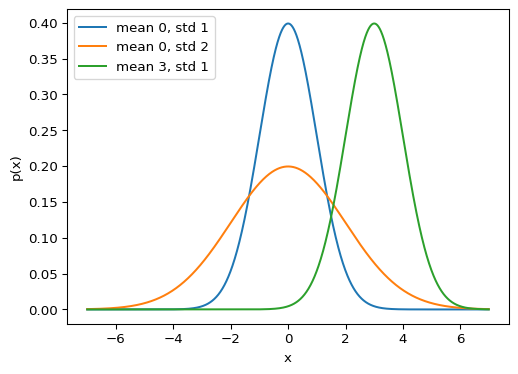

In [8]:
#| echo: true
#| eval: true
#| label: fig-normal_distributions
#| fig-cap: Normal distributions with different means and variances.
#| fig-alt: A line plot of three normal distributions with different means and variances.
#| fig-align: center

# Use NumPy again for visualization
x = np.arange(-7, 7, 0.01)
params = [(0, 1), (0, 2), (3, 1)]

# Mean and standard deviation pairs
plt.figure(figsize=(5.5, 4.0))

for mu, sigma in params:
    plt.plot(x, normal_np(x, mu, sigma), label=f"mean {mu}, std {sigma}")

plt.xlabel("x")
plt.ylabel("p(x)")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
#| echo: true
#| eval: true

import time
import numpy as np
import torch
from torch import nn
import tensorflow as tf

In [10]:
#| echo: true
#| eval: true
def add_to_class(Class):  #@save
    """Register functions as methods in created class."""
    def wrapper(obj):
        setattr(Class, obj.__name__, obj)
    return wrapper

In [11]:
#| echo: true
#| eval: true
class A:
    def __init__(self):
        self.b = 1

a = A()

In [12]:
#| echo: true
#| eval: true

@add_to_class(A)
def do(self):
    print('Class attribute "b" is', self.b)

a.do()

Class attribute "b" is 1


In [13]:
#| echo: true
#| eval: true

import inspect

class HyperParameters:
    def save_hyperparameters(self, ignore=None):
        if ignore is None:
            ignore = []

        frame = inspect.currentframe().f_back
        args = inspect.getargvalues(frame).locals

        self.hparams = {
            k: v for k, v in args.items()
            if k not in ignore and k != 'self' and not k.startswith('_')
        }

        for k, v in self.hparams.items():
            setattr(self, k, v)

In [14]:
#| echo: true
#| eval: true

# Call the fully implemented HyperParameters class
class B(HyperParameters):
    def __init__(self, a, b, c):
        self.save_hyperparameters(ignore=['c'])
        print('self.a =', self.a, 'self.b =', self.b)
        print('There is no self.c =', not hasattr(self, 'c'))


b = B(a=1, b=2, c=3)

self.a = 1 self.b = 2
There is no self.c = True


In [15]:
#| echo: true
#| eval: true

import inspect
import collections
import matplotlib.pyplot as plt
from IPython import display

class ProgressBoard(HyperParameters):
    """Animated plotting of streaming data."""
    def __init__(self, xlabel=None, ylabel=None, xlim=None, ylim=None,
                 xscale='linear', yscale='linear',
                 ls=('-', '--', '-.', ':'), colors=('C0', 'C1', 'C2', 'C3'),
                 fig=None, axes=None, figsize=(5.5, 3.5), display=True):
        self.save_hyperparameters()

    def draw(self, x, y, label, every_n=1):
        Point = collections.namedtuple('Point', ['x', 'y'])

        if not hasattr(self, 'raw_points'):
            self.raw_points = collections.OrderedDict()
            self.data = collections.OrderedDict()

        if label not in self.raw_points:
            self.raw_points[label] = []
            self.data[label] = []

        points = self.raw_points[label]
        line = self.data[label]
        points.append(Point(x, y))

        if len(points) != every_n:
            return

        mean = lambda xs: sum(xs) / len(xs)
        line.append(Point(mean([p.x for p in points]),
                          mean([p.y for p in points])))
        points.clear()

        if not self.display:
            return

        if self.fig is None:
            self.fig = plt.figure(figsize=self.figsize)

        plt.clf()
        ax = self.axes if self.axes else plt.gca()

        for (k, v), ls, color in zip(self.data.items(), self.ls, self.colors):
            ax.plot([p.x for p in v], [p.y for p in v],
                    linestyle=ls, color=color, label=k)

        if self.xlim: ax.set_xlim(self.xlim)
        if self.ylim: ax.set_ylim(self.ylim)
        if self.xlabel: ax.set_xlabel(self.xlabel)
        if self.ylabel: ax.set_ylabel(self.ylabel)
        ax.set_xscale(self.xscale)
        ax.set_yscale(self.yscale)
        ax.legend()

        display.display(self.fig)
        display.clear_output(wait=True)

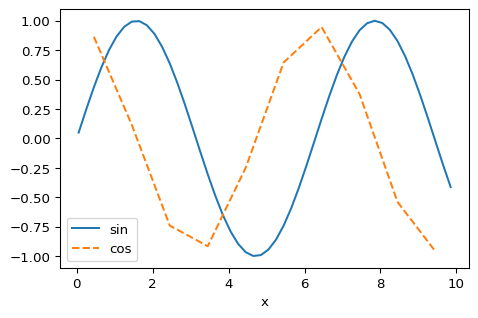

In [16]:
#| echo: true
#| eval: true
#| fig-align: center
#| fig-alt: A line plot of the sine and cosine functions with different smoothness.
#| fig-cap: The sine and cosine functions with different smoothness.
#| label: fig-sin_cos

import numpy as np

board = ProgressBoard('x')
for x in np.arange(0, 10, 0.1):
    board.draw(x, np.sin(x), 'sin', every_n=2)
    board.draw(x, np.cos(x), 'cos', every_n=10)

In [17]:
#| echo: true
#| eval: true
import torch
import torch.nn as nn
import numpy as np

class Module(nn.Module, HyperParameters):
    """Base class for models with training/validation hooks and plotting."""
    def __init__(self, plot_train_per_epoch=2, plot_valid_per_epoch=1):
        nn.Module.__init__(self)
        HyperParameters.__init__(self)
        self.save_hyperparameters()
        self.board = ProgressBoard()

    def loss(self, y_hat, y):
        raise NotImplementedError

    def forward(self, X):
        assert hasattr(self, 'net'), "Define self.net in your subclass"
        return self.net(X)

    def plot(self, key, value, train):
        assert hasattr(self, 'trainer'), "Trainer must set self.trainer"

        self.board.xlabel = "epoch"

        if train:
            x = self.trainer.train_batch_idx / self.trainer.num_train_batches
            n = self.trainer.num_train_batches / self.plot_train_per_epoch
        else:
            x = self.trainer.epoch + 1
            n = self.trainer.num_val_batches / self.plot_valid_per_epoch

        v = value.detach().cpu().numpy() if torch.is_tensor(value) else float(value)
        label = ("train_" if train else "val_") + key
        self.board.draw(x, v, label, every_n=int(n))

    def training_step(self, batch):
        X, y = batch[:-1], batch[-1]
        y_hat = self(*X)
        l = self.loss(y_hat, y)
        self.plot("loss", l, train=True)
        return l

    def validation_step(self, batch):
        X, y = batch[:-1], batch[-1]
        y_hat = self(*X)
        l = self.loss(y_hat, y)
        self.plot("loss", l, train=False)

    def configure_optimizers(self):
        raise NotImplementedError

In [18]:
#| echo: true
#| eval: true

from torch.utils.data import DataLoader

class DataModule(HyperParameters):
    """Base class for datasets and dataloaders."""
    def __init__(self, root="../data", num_workers=4, batch_size=32):
        self.save_hyperparameters()

    def get_dataloader(self, train):
        raise NotImplementedError

    def train_dataloader(self):
        return self.get_dataloader(train=True)

    def val_dataloader(self):
        return self.get_dataloader(train=False)

In [19]:
#| echo: true
#| eval: true

import torch
from torch.utils.data import DataLoader

class Trainer(HyperParameters):
    """Minimal training loop compatible with the custom Module class."""
    def __init__(self, max_epochs=10, device=None):
        self.save_hyperparameters()
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    def prepare_batch(self, batch):
        return [b.to(self.device) for b in batch]

    def fit(self, model, train_loader, val_loader=None):
        model.trainer = self
        model.to(self.device)

        optimizer = model.configure_optimizers()

        self.num_train_batches = len(train_loader)
        self.num_val_batches = len(val_loader) if val_loader else 0

        for epoch in range(self.max_epochs):
            self.epoch = epoch
            model.train()
            for batch_idx, batch in enumerate(train_loader):
                self.train_batch_idx = batch_idx
                batch = self.prepare_batch(batch)
                loss = model.training_step(batch)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            if val_loader:
                model.eval()
                with torch.no_grad():
                    for batch in val_loader:
                        batch = self.prepare_batch(batch)
                        model.validation_step(batch)